# 01 — Exploratory Data Analysis (EDA)
## Fetal Health Classification — Group 16

**Purpose:** This notebook performs exploratory data analysis on the UCI CTG dataset.
EDA is purely observational — no changes are made to the data itself.
Findings directly inform Section 3 of the preliminary report.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
print("Libraries Loaded Successfully")

Libraries Loaded Successfully


## 1. Data Loading
The raw CTG.xls file contains duplicate columns and header rows requiring careful parsing.
Columns with 'nan' names are dropped and all values are converted to numeric format.
Duplicate rows are removed at this stage.

In [29]:
file_path = Path("../data/raw/CTG.xls")
raw_df = pd.read_excel(file_path, sheet_name="Data", header=None)

columns = raw_df.iloc[1].astype(str)
new_cols = []
counts = {}
for col in columns:
    if col in counts:
        counts[col] += 1
        new_cols.append(f"{col}_{counts[col]}")
    else:
        counts[col] = 0
        new_cols.append(col)

df = raw_df.iloc[2:].copy()
df.columns = new_cols

df = df.loc[:, ~df.columns.str.contains('nan', na=True)]

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.drop_duplicates().reset_index(drop=True)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)
print("NSP in columns:", "NSP" in df.columns)

Dataset Loaded Successfully
Shape: (2119, 42)
NSP in columns: True


## 2. Feature Selection
The raw XLS file contains 42 columns including duplicate columns and expert annotation columns
(CLASS, SUSP, A, B, C, D, E etc.) which are excluded to prevent data leakage.
Only the 21 clinically relevant CTG features plus the NSP target variable are retained.

In [30]:
# Keep only first occurrence of each column name
df = df.loc[:, ~df.columns.duplicated()]
df = df.drop_duplicates().reset_index(drop=True)

# Keep only the 21 CTG features + NSP target
ctg_features = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 
                'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 
                'Mode', 'Mean', 'Median', 'Variance', 'Tendency', 'NSP']

df = df[ctg_features].copy()
df = df.drop_duplicates().reset_index(drop=True)

print("Final Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Missing Values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

Final Dataset Shape: (2115, 22)
Columns: ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency', 'NSP']
Missing Values: 54
Duplicates: 0


## 3. Missing Value Analysis
Missing values are identified across all 21 features before any cleaning.
Only 0.12% of values are missing — distributed across multiple columns with a maximum of 3 per feature.
Rows with missing NSP target values are removed as they cannot contribute to supervised classification.

Missing Values Per Column
LB          3
AC          3
Tendency    3
Variance    3
Median      3
Mean        3
Mode        3
Nzeros      3
Nmax        3
Max         3
Min         3
Width       3
NSP         3
MLTV        2
ALTV        2
MSTV        2
ASTV        2
UC          2
FM          2
DP          1
DS          1
DL          1
dtype: int64

Total missing: 54
% of dataset: 0.12%


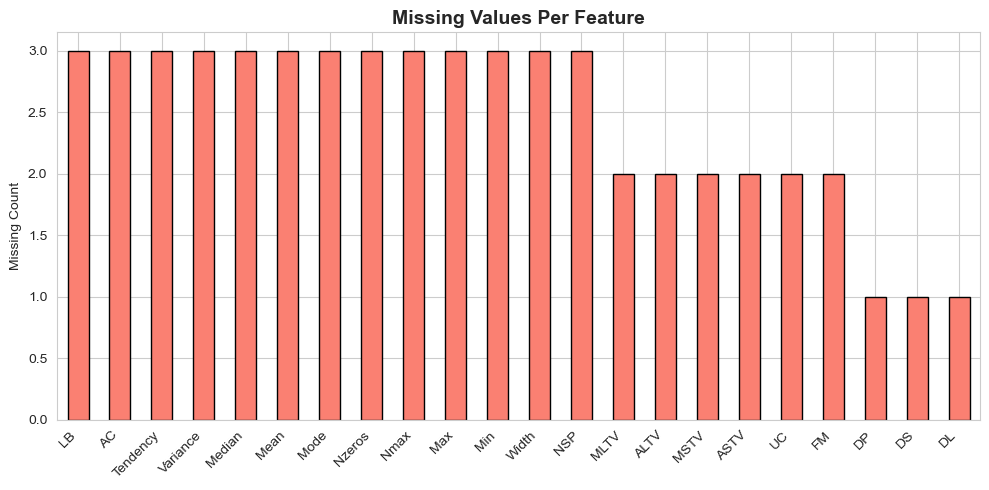


After dropping rows with missing NSP:
Shape: (2112, 22)
Remaining missing values: 0


In [31]:
missing_per_col = df.isnull().sum()
missing_per_col = missing_per_col[missing_per_col > 0].sort_values(ascending=False)

print("Missing Values Per Column")
print("="*50)

if missing_per_col.empty:
    print("No missing values found — dataset is clean!")
else:
    print(missing_per_col)
    print(f"\nTotal missing: {missing_per_col.sum()}")
    print(f"% of dataset: {round(missing_per_col.sum() / (df.shape[0] * df.shape[1]) * 100, 2)}%")

    plt.figure(figsize=(10, 5))
    missing_per_col.plot(kind="bar", color="salmon", edgecolor="black")
    plt.title("Missing Values Per Feature", fontsize=14, fontweight="bold")
    plt.ylabel("Missing Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("../figures/missing_values.png", dpi=300, bbox_inches="tight")
    plt.show()

# Drop rows where NSP is missing
df = df.dropna(subset=["NSP"]).reset_index(drop=True)

print("\nAfter dropping rows with missing NSP:")
print("Shape:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())

## 4. Data Quality Summary
| Metric | Value |
|--------|-------|
| Final shape | 2,112 rows × 22 columns |
| Missing values | 0 (after NSP row removal) |
| Duplicates | 0 |
| Missingness | 0.12% — negligible |

**Conclusion:** The dataset is of high quality and requires minimal cleaning before modelling.

Fetal Health Class Distribution
Normal (1): 1646
Suspect (2): 292
Pathological (3): 174

Class Distribution Percentages
Class 1: 77.94%
Class 2: 13.83%
Class 3: 8.24%

Imbalance Ratio (Normal:Pathological): 9.46:1
SMOTE recommended to address class imbalance


/var/folders/vz/tqx65hv94_15ytcmd818xpvw0000gn/T/ipykernel_81502/3871095842.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["NSP"], palette="Set2", ax=axes[0])


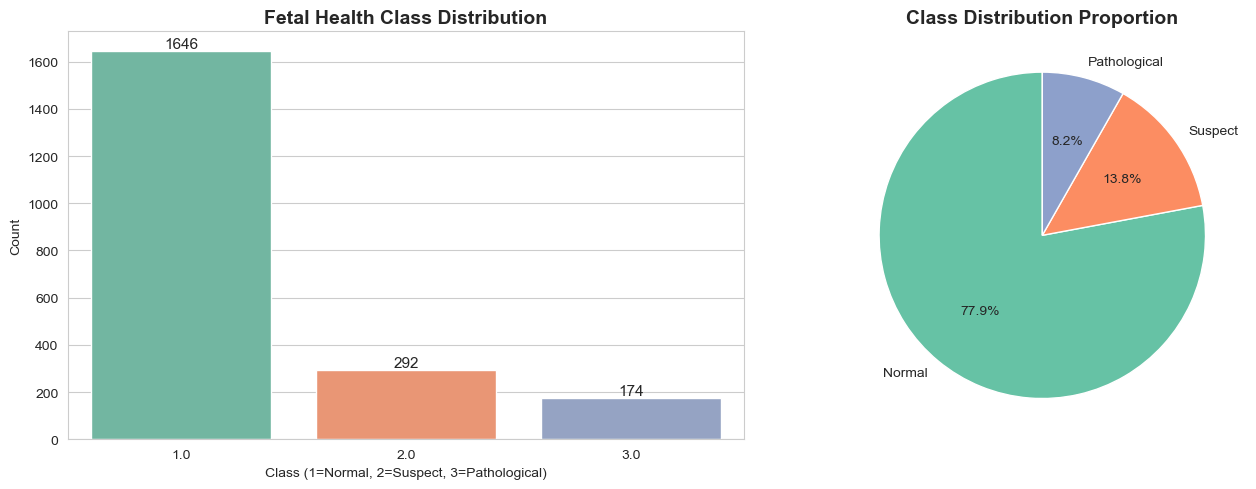

Figure saved: class_distribution.png


In [32]:
class_counts = df["NSP"].value_counts().sort_index()
total = len(df)

print("Fetal Health Class Distribution")
print("="*50)
print("Normal (1):", class_counts[1.0])
print("Suspect (2):", class_counts[2.0])
print("Pathological (3):", class_counts[3.0])

print("\nClass Distribution Percentages")
print("="*50)
for cls, count in class_counts.items():
    percentage = round((count/total)*100, 2)
    print(f"Class {int(cls)}: {percentage}%")

majority = class_counts[1.0]
minority = class_counts[3.0]
imbalance_ratio = round(majority/minority, 2)
print(f"\nImbalance Ratio (Normal:Pathological): {imbalance_ratio}:1")
print("SMOTE recommended to address class imbalance")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x=df["NSP"], palette="Set2", ax=axes[0])
axes[0].set_title("Fetal Health Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Class (1=Normal, 2=Suspect, 3=Pathological)")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

axes[1].pie(class_counts.values, 
            labels=["Normal", "Suspect", "Pathological"],
            autopct="%1.1f%%", 
            colors=["#66c2a5", "#fc8d62", "#8da0cb"],
            startangle=90)
axes[1].set_title("Class Distribution Proportion", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("../figures/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved: class_distribution.png")

## 5. Class Distribution & Imbalance
| Class | Count | Percentage |
|-------|-------|------------|
| Normal (1) | 1,646 | 77.94% |
| Suspect (2) | 292 | 13.83% |
| Pathological (3) | 174 | 8.24% |

**Imbalance ratio: 9.46:1 (Normal:Pathological)**

**Implication:** The severe class imbalance means standard classifiers will be biased toward 
the Normal class, risking poor detection of clinically critical Pathological cases.
SMOTE will be applied during preprocessing to balance class representation.

In [33]:
ctg_features = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 
                'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 
                'Mode', 'Mean', 'Median', 'Variance', 'Tendency']

summary_stats = df[ctg_features].describe().T[["mean", "std", "min", "max"]]
summary_stats = summary_stats.round(3)

print("Summary Statistics — 21 CTG Features")
print("="*50)
print(summary_stats)

summary_stats.to_csv("../data/summary_statistics.csv")
print("\nSaved to data/summary_statistics.csv")

Summary Statistics — 21 CTG Features
             mean     std    min    max
LB        133.297   9.833  106.0  160.0
AC          2.734   3.568    0.0   26.0
FM          7.268  37.244    0.0  564.0
UC          3.679   2.845    0.0   23.0
DL          1.580   2.504    0.0   16.0
DS          0.003   0.057    0.0    1.0
DP          0.127   0.466    0.0    4.0
ASTV       46.979  17.168   12.0   87.0
MSTV        1.336   0.884    0.2    7.0
ALTV        9.760  18.270    0.0   91.0
MLTV        8.169   5.633    0.0   50.7
Width      70.566  38.991    3.0  180.0
Min        93.539  29.546   50.0  159.0
Max       164.106  17.947  122.0  238.0
Nmax        4.079   2.952    0.0   18.0
Nzeros      0.326   0.708    0.0   10.0
Mode      137.448  16.404   60.0  187.0
Mean      134.593  15.611   73.0  182.0
Median    138.083  14.480   77.0  186.0
Variance   18.916  29.043    0.0  269.0
Tendency    0.319   0.611   -1.0    1.0

Saved to data/summary_statistics.csv


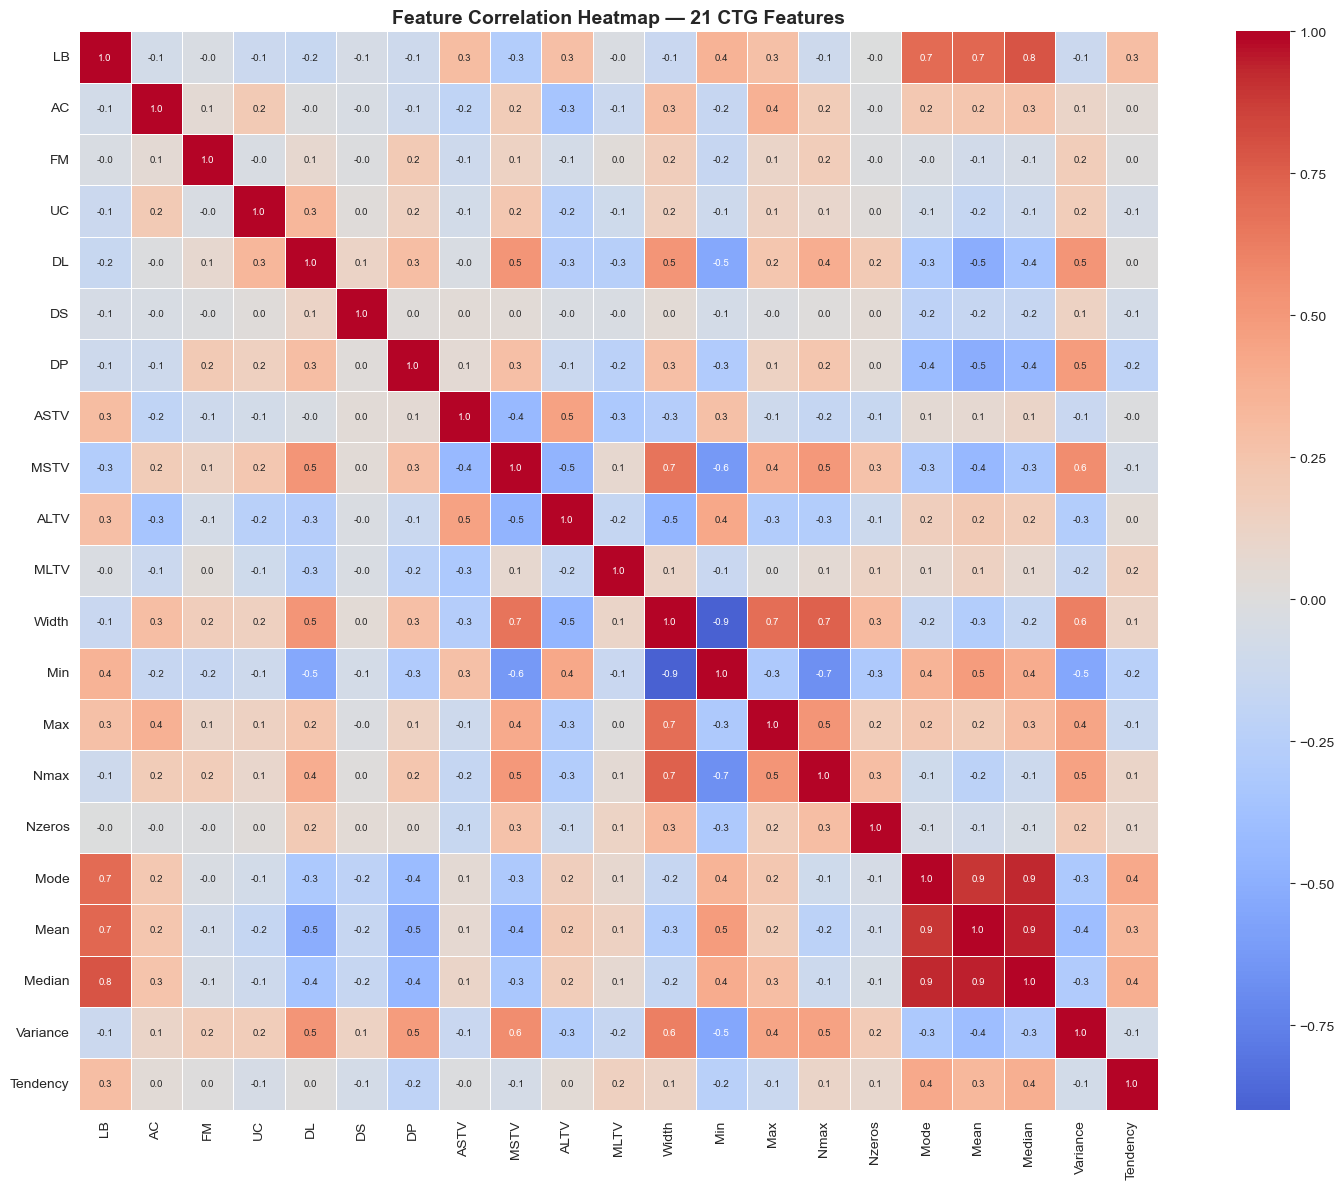

Figure saved: correlation_heatmap.png


In [34]:
corr_matrix = df[ctg_features].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    annot_kws={"size": 7}
)
plt.title("Feature Correlation Heatmap — 21 CTG Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved: correlation_heatmap.png")

## 7. Feature Correlation Analysis
The heatmap reveals several important relationships:
- **Strong multicollinearity** between Mode, Mean and Median (r > 0.7) — highly redundant histogram features
- **Very strong negative correlation** between Width and Min (r = -0.9) — the strongest relationship in the dataset, indicating these two features carry almost identical information
- **LB correlates strongly** with Mode, Mean and Median (r > 0.7)
- **ASTV and MSTV** show negative correlation — opposing variability measures
- **Width, Min, Max and Nmax** form a correlated cluster of histogram shape features

**Implication:** Feature selection or dimensionality reduction may be beneficial.
SHAP analysis will identify which features contribute most to model predictions
and help address redundancy between correlated features.

Top 10 Features Correlated with Fetal Health (NSP)
DP          0.493800
ASTV        0.468465
ALTV        0.418722
AC          0.340038
Mode        0.255109
Mean        0.231916
MLTV        0.224893
Median      0.209919
Variance    0.209422
UC          0.162161
Name: NSP, dtype: float64


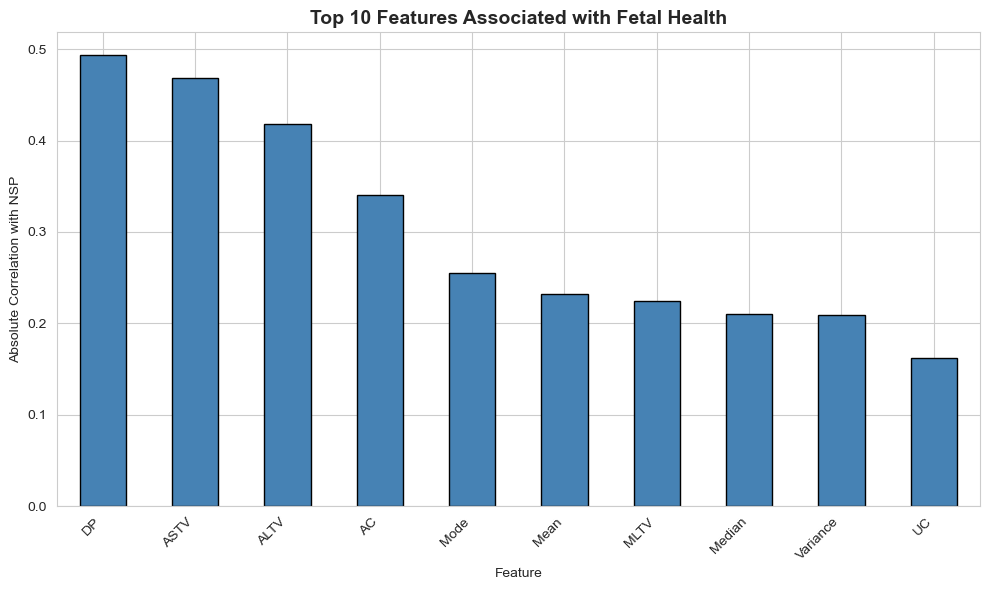

Figure saved: top_features.png


In [35]:
# Fix duplicate NSP column
df = df.loc[:, ~df.columns.duplicated()]

corr_matrix = df[ctg_features + ["NSP"]].corr(numeric_only=True)
nsp_corr = corr_matrix["NSP"].abs()
nsp_corr = nsp_corr.drop("NSP")
top_features = nsp_corr.nlargest(10)

print("Top 10 Features Correlated with Fetal Health (NSP)")
print("="*50)
print(top_features)

plt.figure(figsize=(10, 6))
top_features.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Top 10 Features Associated with Fetal Health", fontsize=14, fontweight="bold")
plt.ylabel("Absolute Correlation with NSP")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/top_features.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved: top_features.png")

## 8. Top Features Associated with Fetal Health
| Feature | Correlation | Clinical Meaning |
|---------|-------------|-----------------|
| DP | 0.494 | Prolonged Decelerations — key distress indicator |
| ASTV | 0.468 | Percentage of time with abnormal short-term variability |
| ALTV | 0.419 | Percentage of time with abnormal long-term variability |
| AC | 0.340 | Accelerations — reduced in fetal distress |
| Mode | 0.255 | Histogram mode of FHR |
| Mean | 0.232 | Histogram mean of FHR |
| MLTV | 0.225 | Mean long-term variability |
| Median | 0.210 | Histogram median of FHR |
| Variance | 0.209 | Histogram variance of FHR |
| UC | 0.162 | Uterine contractions |

**Implication:** DP, ASTV and ALTV are the strongest predictors of fetal distress.
These align with established clinical guidelines and will be prioritised in SHAP explainability analysis.

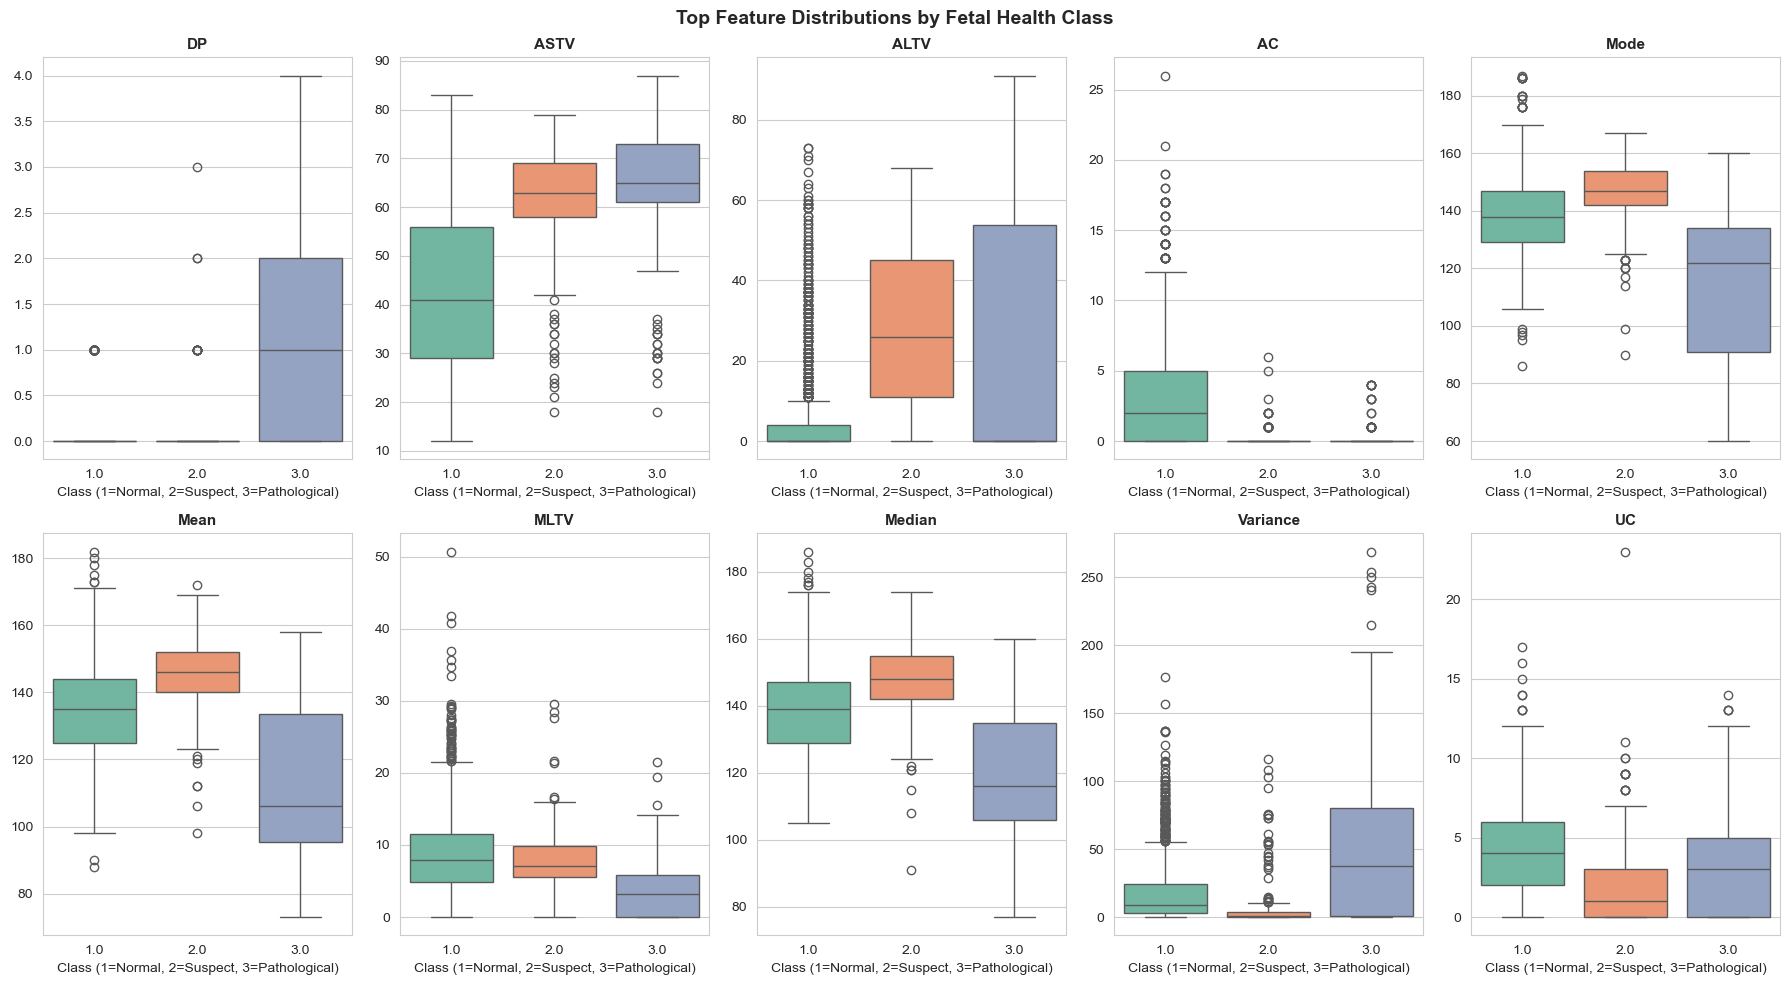

Figure saved: feature_distributions.png


In [36]:
top_feature_names = top_features.index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_feature_names):
    sns.boxplot(x=df["NSP"], y=df[col], hue=df["NSP"], palette="Set2", legend=False, ax=axes[i])
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Class (1=Normal, 2=Suspect, 3=Pathological)")
    axes[i].set_ylabel("")

plt.suptitle("Top Feature Distributions by Fetal Health Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved: feature_distributions.png")

## 9. Feature Distributions by Class
Key observations from boxplots:
- **ASTV** increases significantly from Normal → Suspect → Pathological — strong class separator
- **AC (Accelerations)** decreases as fetal health worsens — clinically consistent with distress
- **Mode and Mean** drop notably in Pathological cases indicating lower baseline FHR
- **Variance** shows extreme outliers in Normal class — requires attention in preprocessing
- **MLTV** decreases in Pathological cases indicating reduced long-term variability
- **DP** near zero in Normal cases but elevated in Pathological — key distress indicator

**Implication:** Clear distributional differences across classes confirm the dataset is 
well-suited for machine learning classification. These patterns support the use of 
tree-based ensemble methods which can capture non-linear relationships between 
features and fetal health status.

## 10. EDA Summary & Implications for Modelling

| Finding | Implication for Project |
|---------|------------------------|
| 9.46:1 class imbalance | Apply SMOTE in preprocessing |
| 0.12% missing values | Row removal sufficient — no imputation needed |
| DP, ASTV, ALTV top features | Prioritise in SHAP analysis |
| Mode/Mean/Median multicollinearity | Consider feature selection |
| Clear class separation in boxplots | Dataset well-suited for ML classification |
| Wide feature ranges | StandardScaler required in preprocessing |
| No severe structural data issues | Dataset is reliable for modelling |

**Overall conclusion:** The UCI CTG dataset is clean, well-structured and suitable for
multi-class fetal health classification. The identified class imbalance and feature 
relationships directly inform the preprocessing and modelling decisions outlined 
in Section 4 of this report.